# Preface

In this notebook, we demonstrate classification using decision trees. We will also demonstrate model ensembling with decision trees.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_context('notebook', font_scale=1.25, rc={"lines.linewidth": 2.5})
sns.set_style("darkgrid")
#np.random.seed(24)  # For reproducibility

# Diabetes Dataset

This dataset is originally from the *National Institute of Diabetes and Digestive and Kidney Diseases*. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

The datasets consists of several medical predictor variables and one target variable, `Outcome` (1 being diabetic and 0 if not). Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

In [3]:
dataset = pd.read_csv('./diabetes.csv')

In [4]:
dataset.head(n=6)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0


## Train Test Split

We are going to split the dataset as usual. This time, we are going to apply cross validation to the training set to evaluate our model for the purpose of model selection and only use the test data for final model evaluation. This is to prevent *overfitting the test set*.

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x, y = dataset[dataset.columns[:-1]], dataset[dataset.columns[-1]]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

# Decision Tree Classification

We first fit a decision tree using `DecisionTreeClassifier` from `sklearn`.

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
clf = DecisionTreeClassifier(max_depth=4, criterion='entropy')
clf.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Cross Validation Scoring

We now use cross-validation scoring on the training set. This gives a better measure of the actual performance of our trained model.

In [9]:
from sklearn.model_selection import cross_val_score

Mean accuracy: 0.7467080745341614
Std accuracy: 0.042311080957712174


<Axes: ylabel='Count'>

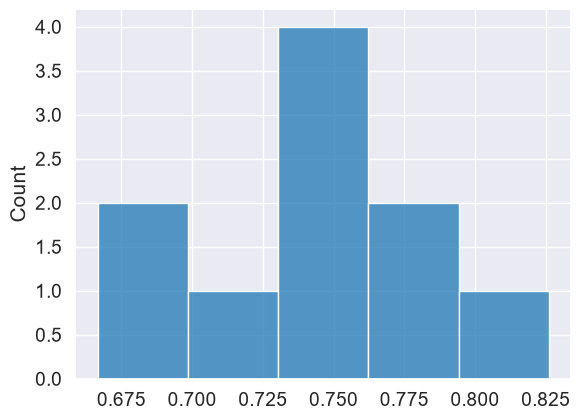

In [10]:
scores = cross_val_score(clf, x_train, y_train, cv=10)
print(f'Mean accuracy: {np.mean(scores)}')
print(f'Std accuracy: {np.std(scores)}')
sns.histplot(scores)

Observe that cross validated accuracies better reflect testing performance!

In [11]:
print(f'Train accuracy: {clf.score(x_train, y_train)}')
print(f'Mean CV accuracy: {np.mean(scores)}')
print(f'Test accuracy: {clf.score(x_test, y_test)}')

Train accuracy: 0.7872648335745297
Mean CV accuracy: 0.7467080745341614
Test accuracy: 0.7272727272727273


## Visualizing the Decision Tree

As mentioned in the lecture, one advantage is that the decision tree can be visualized to see how it arrives at the decision. Let us see how our tree model arrives at a diagnosis of diabetes.

We will use the `plot_tree` from `sklearn.tree` to achieve this. Alternatively, you can also use the [`graphviz` package](https://www.graphviz.org).

In [12]:
from sklearn.tree import plot_tree

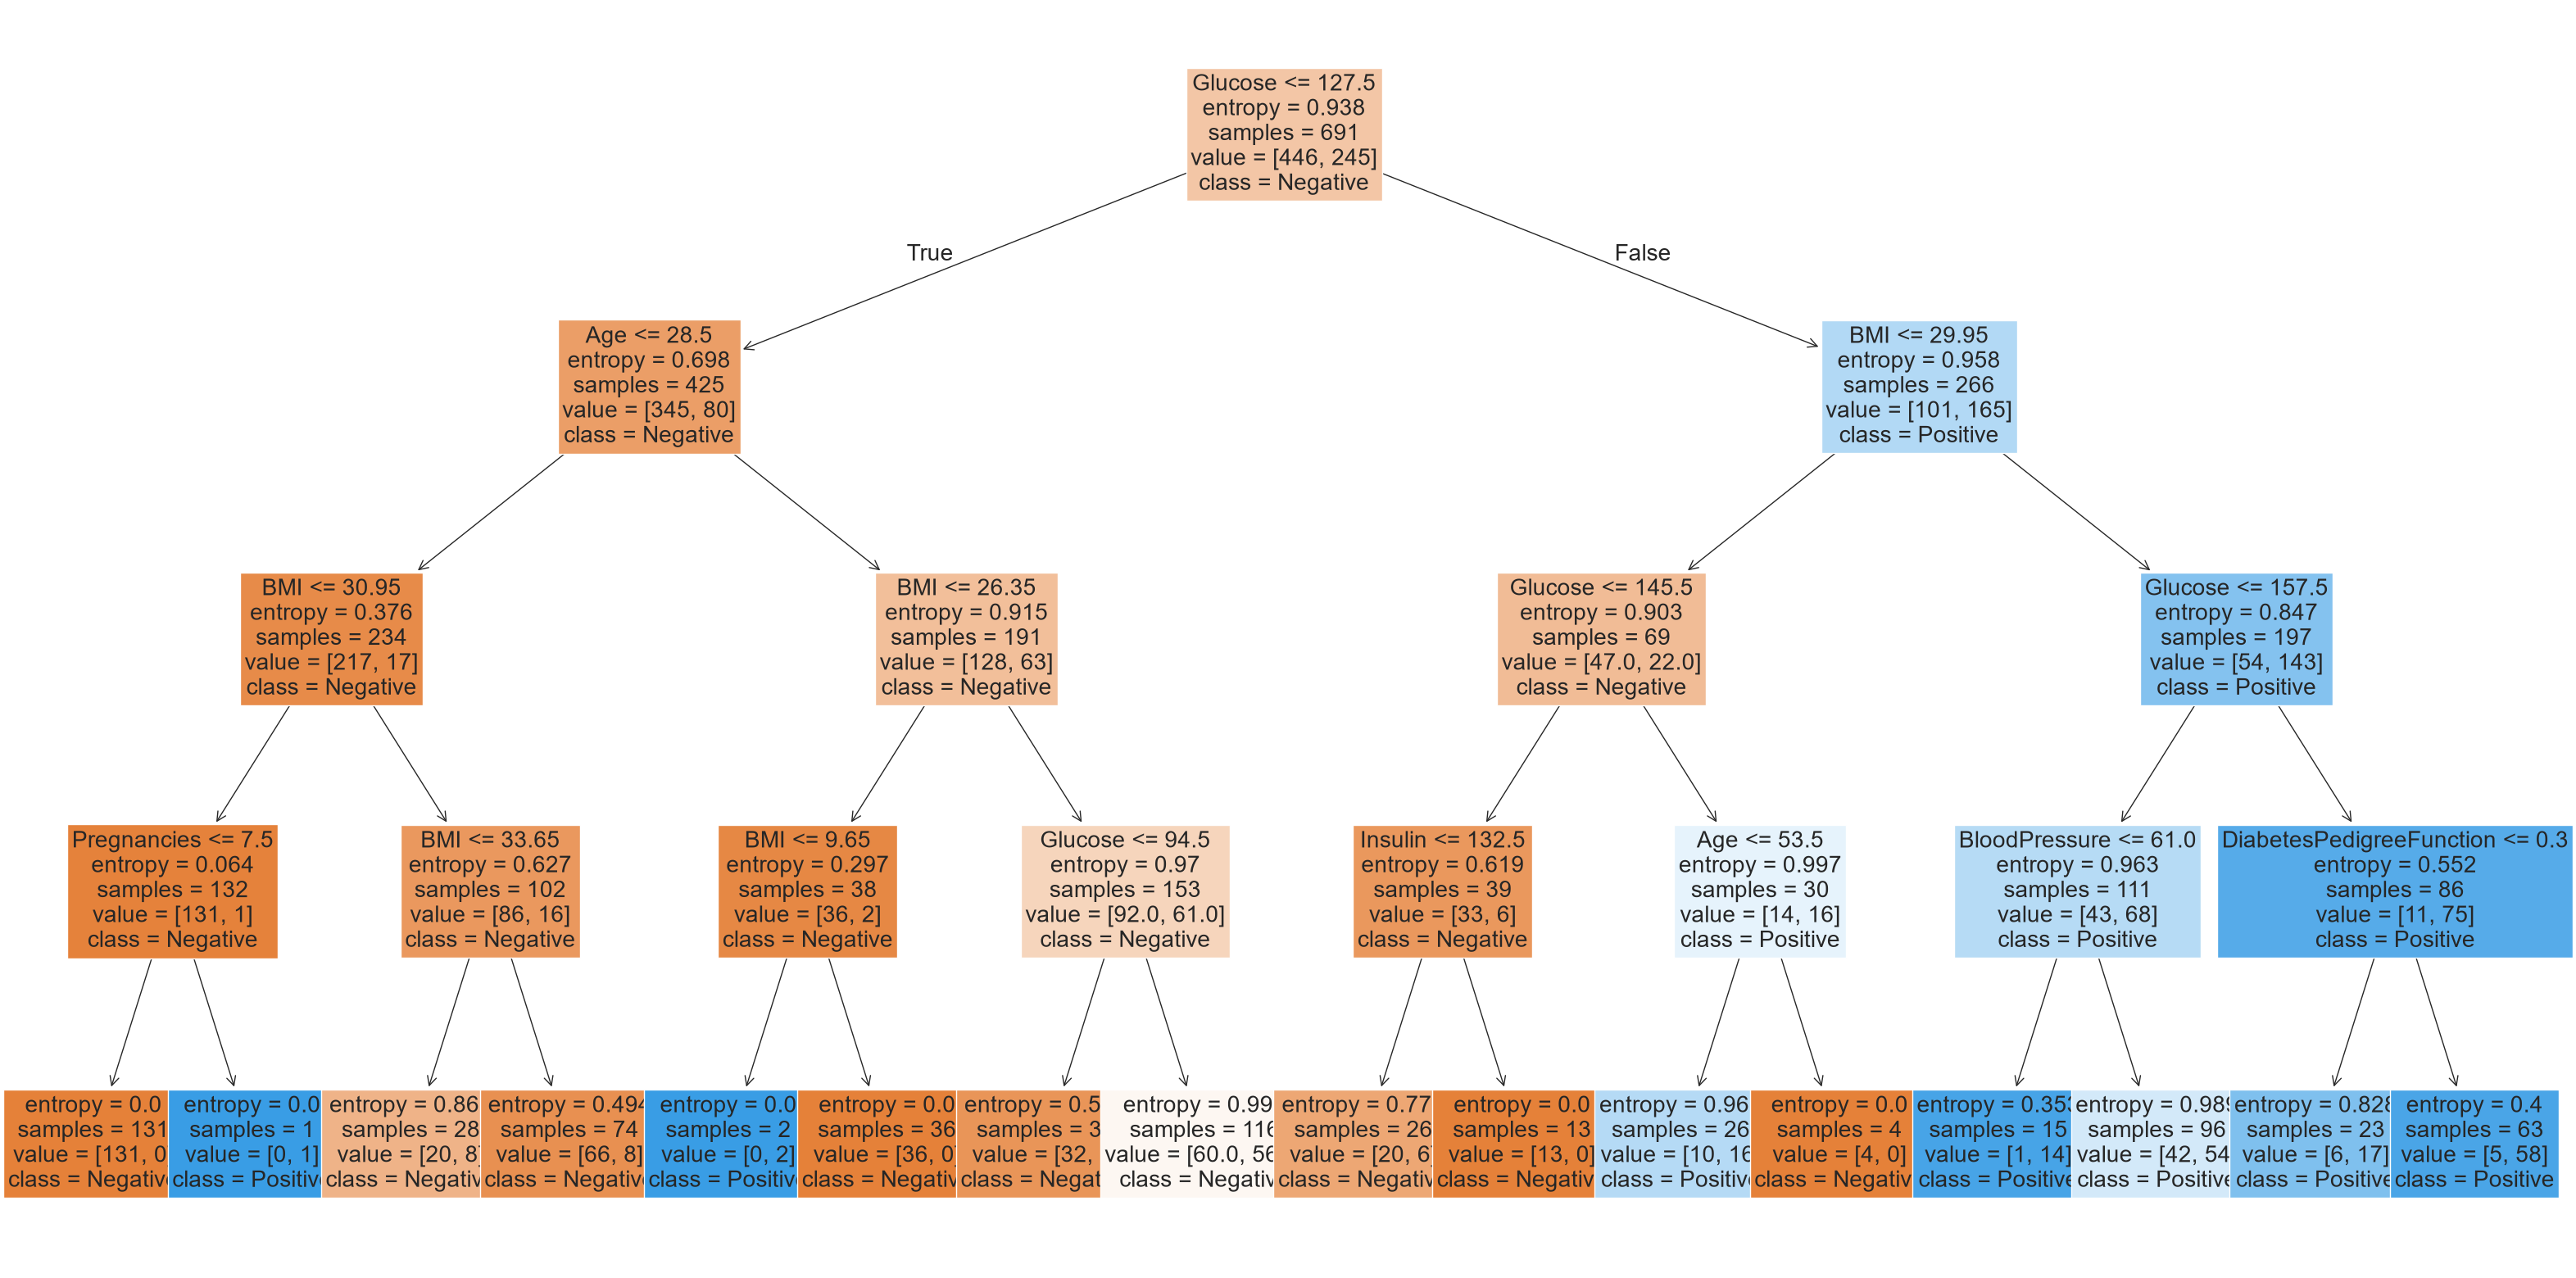

In [13]:
plt.figure(figsize=(40, 20))
plot_tree(
    clf,
    feature_names=dataset.columns[:-1],
    class_names=['Negative', 'Positive'],
    filled=True,
    fontsize=20
);

## Overfitting

Let us now fit a sequence of decision trees with increasing depth. We observe from the results below two things:
  1. As depth increases, we overfit: training accuracy increases but not test
  2. Generally, CV accuracy gives a better prediction of test error

In [14]:
results = []
for depth in range(2, 9):
    clf = DecisionTreeClassifier(max_depth=depth)
    clf.fit(x_train, y_train)
    train_acc = clf.score(x_train, y_train)
    test_acc = clf.score(x_test, y_test)
    cv_acc = np.mean(cross_val_score(clf, x_train, y_train, cv=10))
    results.append([depth, train_acc, test_acc, cv_acc])
results = pd.DataFrame(
    data=results,
    columns=['depth', 'train accuracy', 'test accuracy', 'cv accuracy'],
)
results = pd.melt(
    results,
    id_vars=['depth'],
    var_name='type',
    value_name='accuracy'
)  # Melt dataframe for easier plotting

<Axes: xlabel='depth', ylabel='accuracy'>

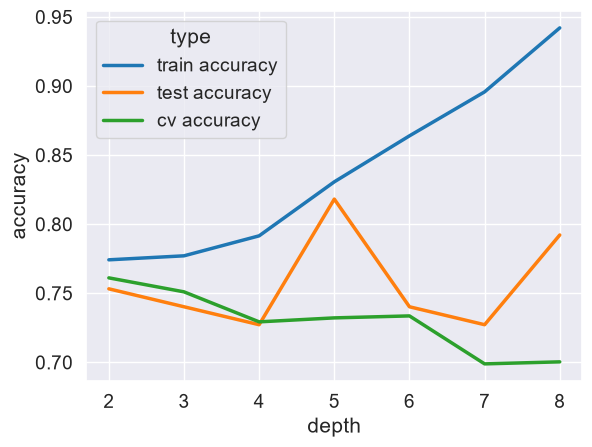

In [15]:
sns.lineplot(
    x='depth',
    y='accuracy',
    hue='type',
    data=results,
)

# Random Forest (Bagging)

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
clf = RandomForestClassifier(n_estimators=100, max_depth=4)
clf.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [18]:
print(f'Train accuracy: {clf.score(x_train, y_train)}')
scores = cross_val_score(clf, x_train, y_train, cv=10)
print(f'Mean CV accuracy: {np.mean(scores)}')
print(f'Test accuracy: {clf.score(x_test, y_test)}')

Train accuracy: 0.8234442836468886
Mean CV accuracy: 0.7669772256728777
Test accuracy: 0.7922077922077922


In [19]:
results_rf = []
for depth in range(2, 9):
    clf = RandomForestClassifier(n_estimators=100, max_depth=depth)
    clf.fit(x_train, y_train)
    train_acc = clf.score(x_train, y_train)
    test_acc = clf.score(x_test, y_test)
    cv_acc = np.mean(cross_val_score(clf, x_train, y_train, cv=12))
    results_rf.append([depth, train_acc, test_acc, cv_acc])
results_rf = pd.DataFrame(
    data=results_rf,
    columns=['depth', 'train accuracy', 'test accuracy', 'cv accuracy'],
)
results_rf = pd.melt(
    results_rf,
    id_vars=['depth'],
    var_name='type',
    value_name='accuracy'
)

Text(0.5, 1.0, 'Random Forest')

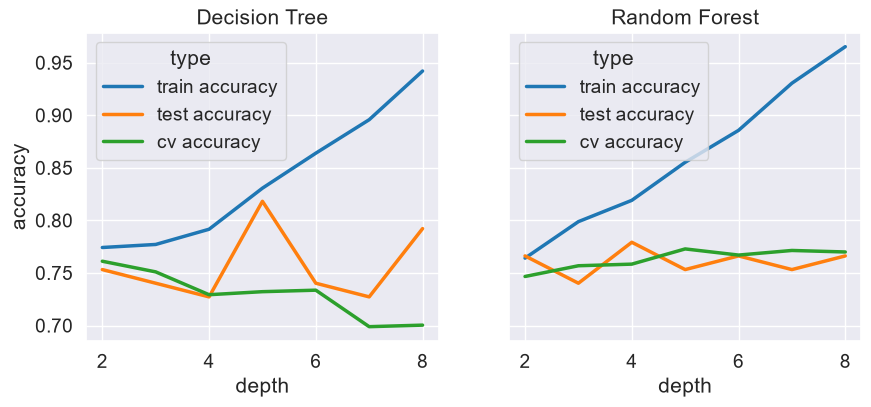

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.lineplot(
    x='depth',
    y='accuracy',
    hue='type',
    data=results,
    ax=ax[0]
)
ax[0].set_title('Decision Tree')

sns.lineplot(
    x='depth',
    y='accuracy',
    hue='type',
    data=results_rf,
    ax=ax[1]
)
ax[1].set_title('Random Forest')

# AdaBoost (Boosting)

In [21]:
from sklearn.ensemble import AdaBoostClassifier

In [22]:
clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=4),
    n_estimators=10, 
)

In [23]:
clf.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=4)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",10
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=4)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](10,)","[0.21,0.25,0.33,...,0.34,0.31,0.33]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](10,)","[1.33,1.09,0.69,...,0.65,0.79,0.71]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1922384510), DecisionTreeC...ate=245511411), DecisionTreeC...te=1166058278), DecisionTreeC...te=1625624430), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](8,)","[0.05,0.25,0.07,...,0.23,0.19,0.13]"


In [24]:
print(f'Train accuracy: {clf.score(x_train, y_train)}')
scores = cross_val_score(clf, x_train, y_train, cv=10)
print(f'Mean CV accuracy: {np.mean(scores)}')
print(f'Test accuracy: {clf.score(x_test, y_test)}')

Train accuracy: 0.8856729377713459
Mean CV accuracy: 0.7394409937888199
Test accuracy: 0.7662337662337663


## Hyper-parameter Tuning

Observe that there are many choices in the `AdaBoost` classifier. We have mostly left everything to their default values.

In [25]:
clf

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=4)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",10
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=4)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](10,)","[0.21,0.25,0.33,...,0.34,0.31,0.33]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](10,)","[1.33,1.09,0.69,...,0.65,0.79,0.71]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1922384510), DecisionTreeC...ate=245511411), DecisionTreeC...te=1166058278), DecisionTreeC...te=1625624430), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](8,)","[0.05,0.25,0.07,...,0.23,0.19,0.13]"


In practice, however, to obtain good performance we should perform *hyper-parameter tuning*. This means that we should pick the parameters (e.g. `max_depth`, `criterion`, `learning_rate`, `n_estimators` etc) to maximize performance. 

How do we judge performance? We use cross-validation on the training set!

In [26]:
from sklearn.model_selection import GridSearchCV

First, we check what parameters are adjustable using `clf.get_params()`. 

**Note: make sure you understand what these parameters mean!**

In [27]:
clf.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'gini',
 'estimator__max_depth': 4,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': None,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(max_depth=4),
 'learning_rate': 1.0,
 'n_estimators': 10,
 'random_state': None}

Next we set up parameter grids and apply `GridSearchCV`. This will take some time...

In [28]:
param_grid = {
    'estimator__max_depth': [2, 3, 4, 5],
    'estimator__criterion': ['gini', 'entropy'],
    'n_estimators': [25, 50, 75],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

In [29]:
clf_grid = GridSearchCV(estimator=clf, param_grid=param_grid, cv=8)

Here the ``cv`` argument is the number of folds of cross validation.

In [30]:
clf_grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...estimators=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__criterion': ['gini', 'entropy'], 'estimator__max_depth': [2, 3, ...], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [25, 50, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for cal

In [31]:
clf_grid.best_params_

{'estimator__criterion': 'gini',
 'estimator__max_depth': 2,
 'learning_rate': 1.0,
 'n_estimators': 50}

In [32]:
print(f'Train accuracy: {clf_grid.score(x_train, y_train)}')
print(f'Test accuracy: {clf_grid.score(x_test, y_test)}')

Train accuracy: 0.8437047756874095
Test accuracy: 0.7662337662337663


# Final Remarks

So we have improved our results by cross-validation grid search over some hyper-parameters. What if the parameter space is very large so that grid search is impossible? You may check `sklearn.model_selection.RandomizedSearchCV`. 

Another boosting algorithm, namely *gradient boosting*, typically gives state of the art results on a variety of tasks. For details, check the following resources:
   * [Gradient boosting on sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
   * [xgboost](https://xgboost.readthedocs.io/en/latest/python/python_intro.html): another implementation, generally faster/better than sklearn's
   
Remember to perform hyperparameter tuning! The defaults can be very bad for some applications.